<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.84MB/s    in 41s     

2026-09-30 13:53:43 (3.72 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



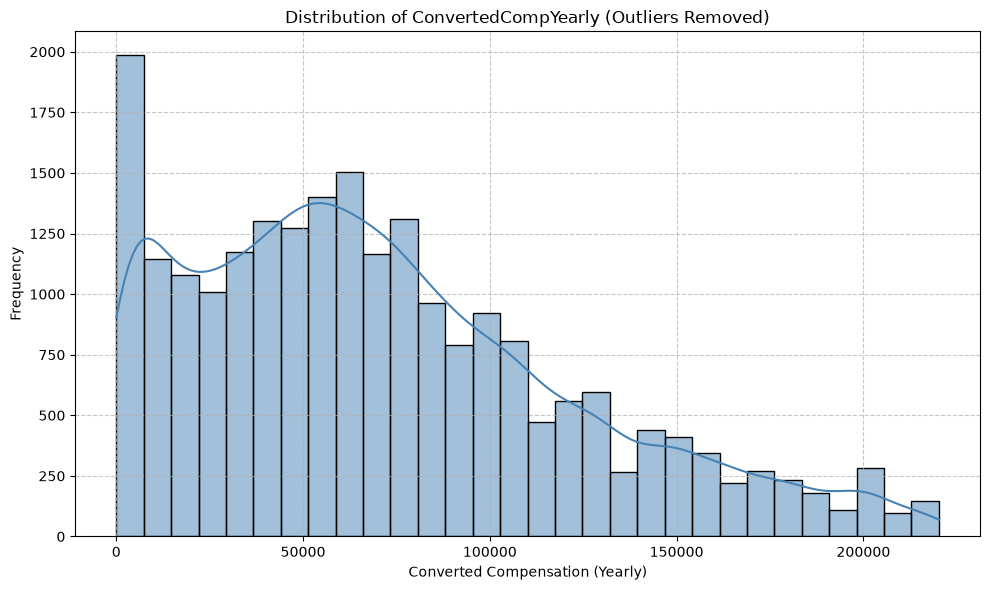

In [3]:
# Select column
plot_df = df[['ConvertedCompYearly']].copy()

# Convert to numeric
plot_df['ConvertedCompYearly'] = pd.to_numeric(
    plot_df['ConvertedCompYearly'],
    errors='coerce'
)

# Remove missing values
plot_df = plot_df.dropna()

# Remove outliers using IQR
Q1 = plot_df['ConvertedCompYearly'].quantile(0.25)
Q3 = plot_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_df = plot_df[
    (plot_df['ConvertedCompYearly'] >= lower_bound) &
    (plot_df['ConvertedCompYearly'] <= upper_bound)
]

# Create histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_df,
    x='ConvertedCompYearly',
    bins=30,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of ConvertedCompYearly (Outliers Removed)')
plt.xlabel('Converted Compensation (Yearly)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



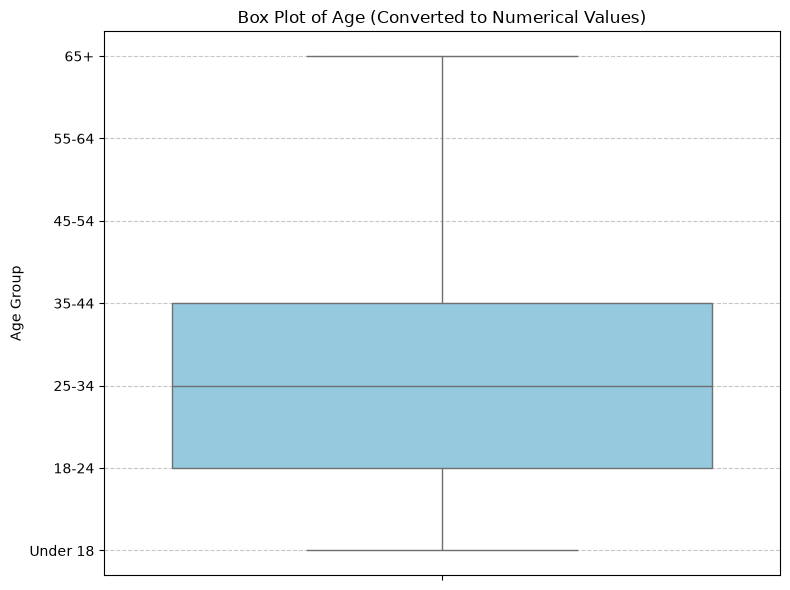

In [4]:
# Select Age column
plot_df = df[['Age']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Convert age groups to ordinal numeric values
age_mapping = {
    'Under 18 years old': 1,
    '18-24 years old': 2,
    '25-34 years old': 3,
    '35-44 years old': 4,
    '45-54 years old': 5,
    '55-64 years old': 6,
    '65 years or older': 7
}

plot_df['Age_Num'] = plot_df['Age'].map(age_mapping)

# Create box plot
plt.figure(figsize=(8, 6))

sns.boxplot(y=plot_df['Age_Num'], color='skyblue')

plt.title('Box Plot of Age (Converted to Numerical Values)')
plt.ylabel('Age Group')

# Replace numeric values with age group labels
plt.yticks(
    [1, 2, 3, 4, 5, 6, 7],
    [
    'Under 18',
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
    ]
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



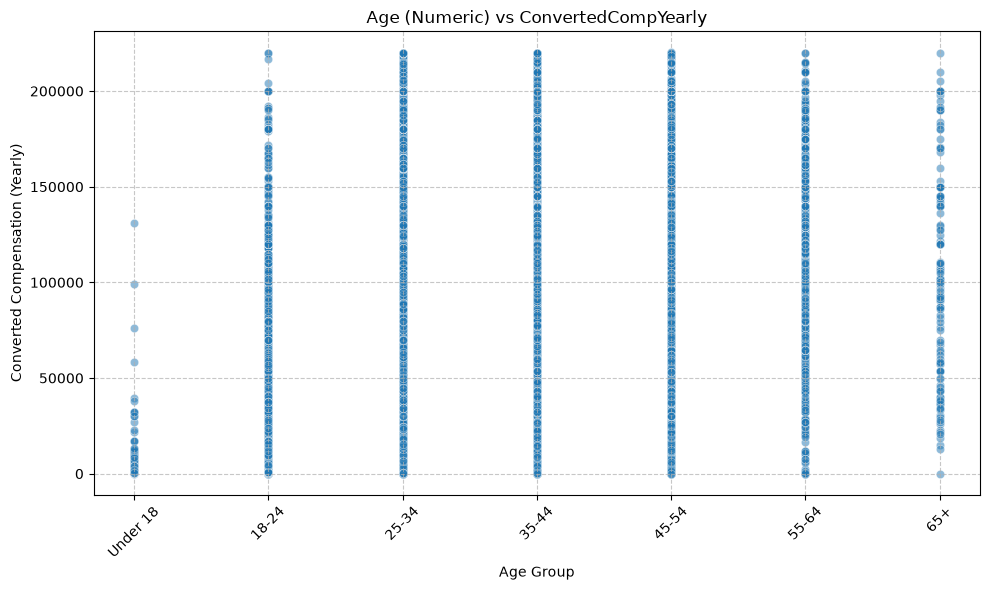

In [5]:
# Select relevant columns
plot_df = df[['Age', 'ConvertedCompYearly']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Convert age groups to numeric values
age_mapping = {
    'Under 18 years old': 1,
    '18-24 years old': 2,
    '25-34 years old': 3,
    '35-44 years old': 4,
    '45-54 years old': 5,
    '55-64 years old': 6,
    '65 years or older': 7
}

plot_df['Age_Num'] = plot_df['Age'].map(age_mapping)

# Convert compensation to numeric
plot_df['ConvertedCompYearly'] = pd.to_numeric(
    plot_df['ConvertedCompYearly'],
    errors='coerce'
)

plot_df = plot_df.dropna()

# Remove compensation outliers using IQR
Q1 = plot_df['ConvertedCompYearly'].quantile(0.25)
Q3 = plot_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_df = plot_df[
    (plot_df['ConvertedCompYearly'] >= lower_bound) &
    (plot_df['ConvertedCompYearly'] <= upper_bound)
]

# Create scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x='Age_Num',
    y='ConvertedCompYearly',
    alpha=0.5
)

plt.title('Age (Numeric) vs ConvertedCompYearly')
plt.xlabel('Age Group')
plt.ylabel('Converted Compensation (Yearly)')

# Replace numeric tick labels with age groups
plt.xticks(
    [1, 2, 3, 4, 5, 6, 7],
    [
    'Under 18',
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65+'
    ],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


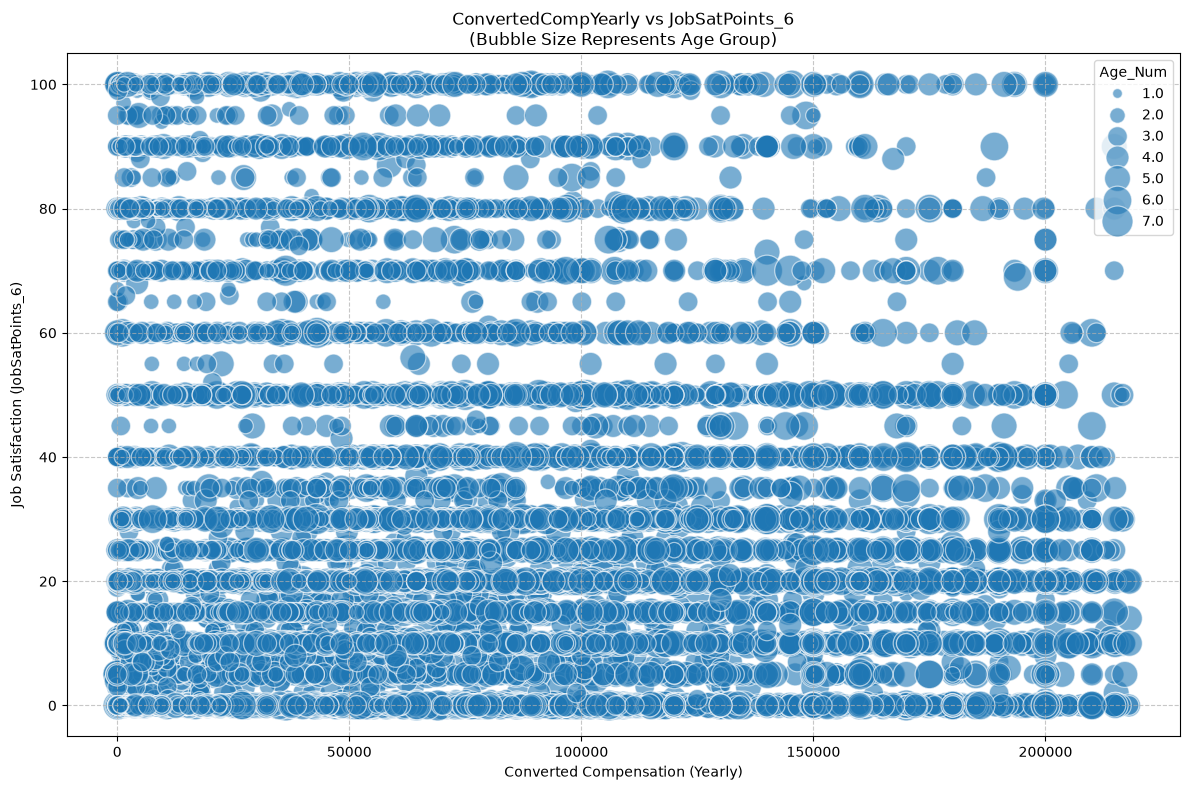

In [6]:
# Select relevant columns
plot_df = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Convert Age to numeric values
age_mapping = {
    'Under 18 years old': 1,
    '18-24 years old': 2,
    '25-34 years old': 3,
    '35-44 years old': 4,
    '45-54 years old': 5,
    '55-64 years old': 6,
    '65 years or older': 7
}

plot_df['Age_Num'] = plot_df['Age'].map(age_mapping)

# Convert columns to numeric
plot_df['ConvertedCompYearly'] = pd.to_numeric(
    plot_df['ConvertedCompYearly'],
    errors='coerce'
)

plot_df['JobSatPoints_6'] = pd.to_numeric(
    plot_df['JobSatPoints_6'],
    errors='coerce'
)

plot_df = plot_df.dropna()

# Remove compensation outliers using IQR
Q1 = plot_df['ConvertedCompYearly'].quantile(0.25)
Q3 = plot_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_df = plot_df[
    (plot_df['ConvertedCompYearly'] >= lower_bound) &
    (plot_df['ConvertedCompYearly'] <= upper_bound)
]

# Create bubble plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_df,
    x='ConvertedCompYearly',
    y='JobSatPoints_6',
    size='Age_Num',
    sizes=(50, 500),
    alpha=0.6,
    legend='full'
)

plt.title('ConvertedCompYearly vs JobSatPoints_6\n(Bubble Size Represents Age Group)')
plt.xlabel('Converted Compensation (Yearly)')
plt.ylabel('Job Satisfaction (JobSatPoints_6)')

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



/tmp/ipykernel_839/3185938208.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

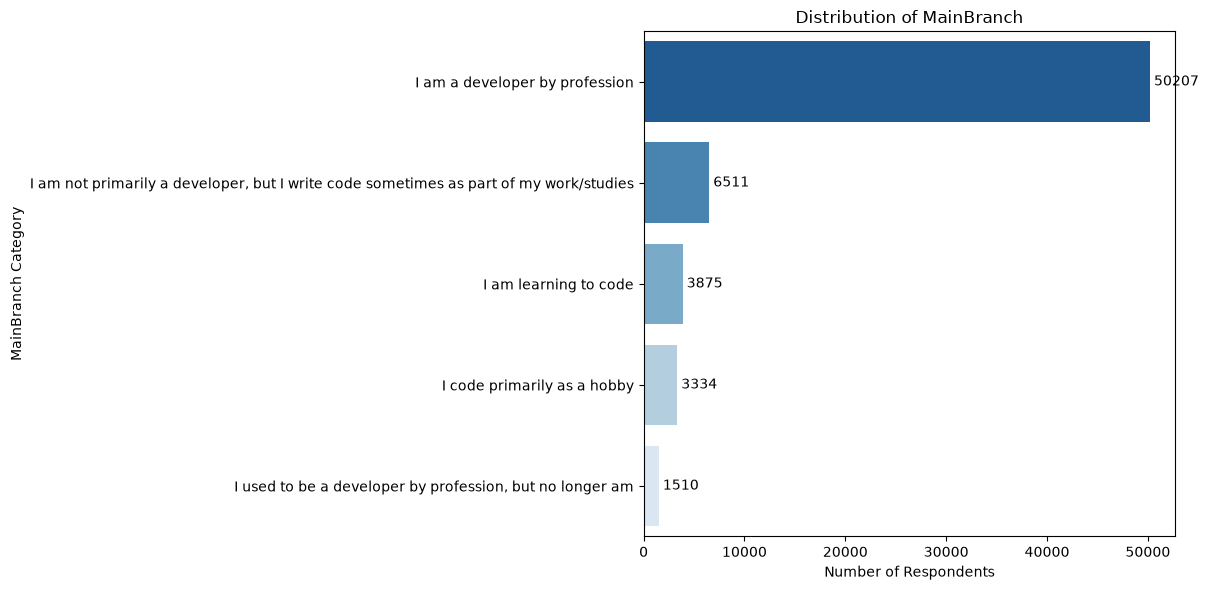

In [7]:
# Select column
plot_df = df[['MainBranch']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Get counts
mainbranch_counts = (
    plot_df['MainBranch']
    .value_counts()
    .reset_index()
)

mainbranch_counts.columns = ['MainBranch', 'Count']

# Create horizontal bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=mainbranch_counts,
    y='MainBranch',
    x='Count',
    palette='Blues_r'
)

plt.title('Distribution of MainBranch')
plt.xlabel('Number of Respondents')
plt.ylabel('MainBranch Category')

# Add count labels
for index, value in enumerate(mainbranch_counts['Count']):
    plt.text(
        value,
        index,
        f' {value}',
        va='center'
    )

plt.tight_layout()
plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



/tmp/ipykernel_839/137425319.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

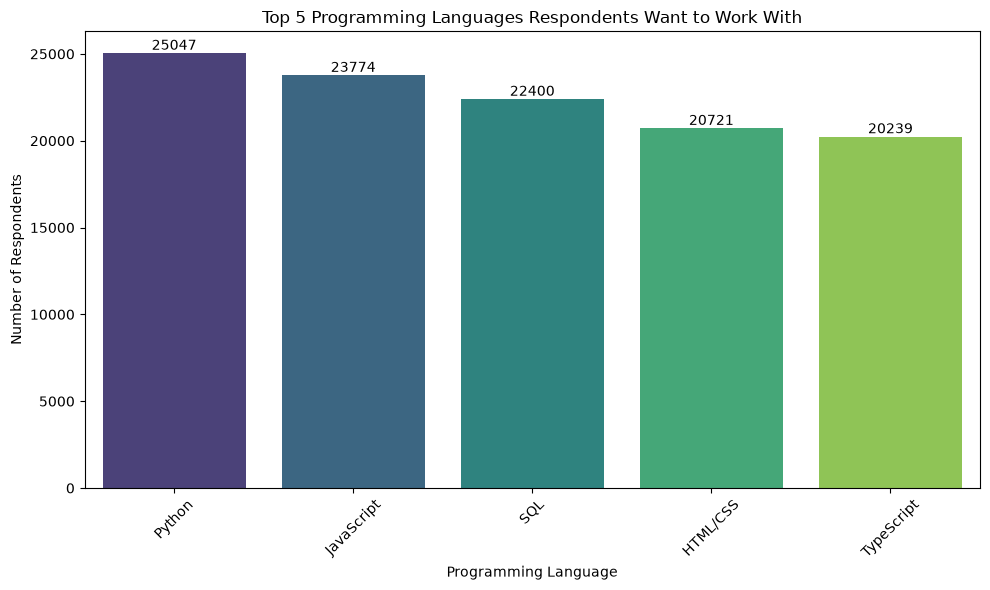

In [8]:
# Select column
plot_df = df[['LanguageWantToWorkWith']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Split multiple languages and count occurrences
language_counts = (
    plot_df['LanguageWantToWorkWith']
    .str.split(';')
    .explode()
    .value_counts()
    .head(5)
    .reset_index()
)

language_counts.columns = ['Language', 'Count']

# Create vertical bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=language_counts,
    x='Language',
    y='Count',
    palette='viridis'
)

plt.title('Top 5 Programming Languages Respondents Want to Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')

# Add value labels
for i, count in enumerate(language_counts['Count']):
    plt.text(
        i,
        count,
        str(count),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


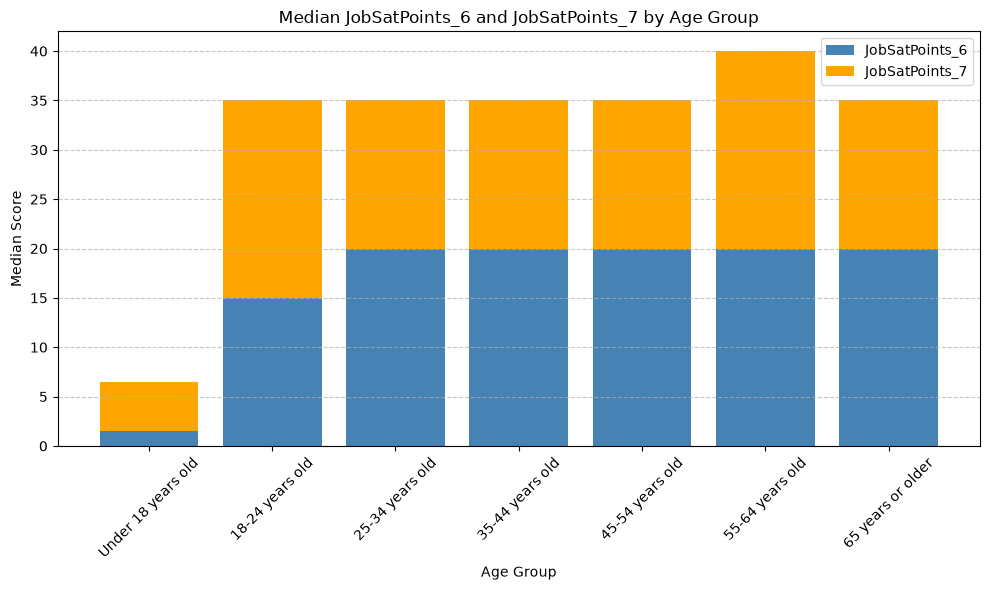

In [10]:
# Select relevant columns
plot_df = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].copy()

# Convert to numeric
plot_df['JobSatPoints_6'] = pd.to_numeric(plot_df['JobSatPoints_6'], errors='coerce')
plot_df['JobSatPoints_7'] = pd.to_numeric(plot_df['JobSatPoints_7'], errors='coerce')

# Remove missing values
plot_df = plot_df.dropna()

# Calculate medians by age group
median_df = (
    plot_df.groupby('Age', as_index=False)
        .agg({
            'JobSatPoints_6': 'median',
            'JobSatPoints_7': 'median'
        })
)

# Define age order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Keep only valid age groups
median_df = median_df[median_df['Age'].isin(age_order)]

# Sort by age order
median_df['Age'] = pd.Categorical(
    median_df['Age'],
    categories=age_order,
    ordered=True
)

median_df = median_df.sort_values('Age')

# Convert Age back to strings for plotting
x = median_df['Age'].astype(str)

# Create stacked bar chart
plt.figure(figsize=(10, 6))

plt.bar(
    x,
    median_df['JobSatPoints_6'],
    label='JobSatPoints_6',
    color='steelblue'
)

plt.bar(
    x,
    median_df['JobSatPoints_7'],
    bottom=median_df['JobSatPoints_6'],
    label='JobSatPoints_7',
    color='orange'
)

plt.title('Median JobSatPoints_6 and JobSatPoints_7 by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Score')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



/tmp/ipykernel_839/316581027.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

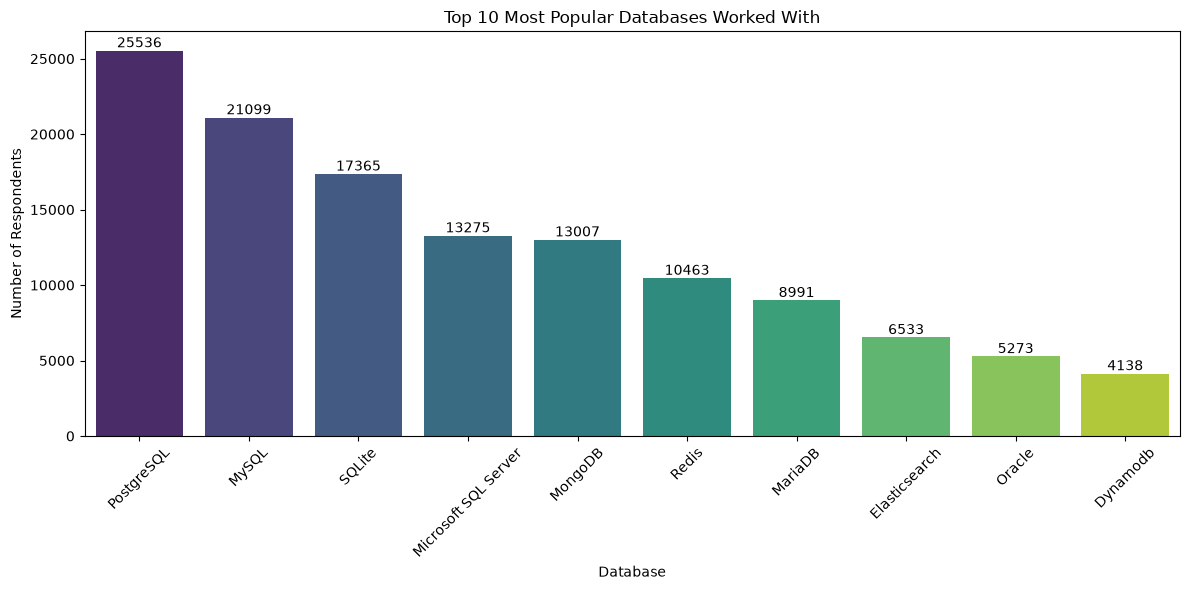

In [11]:
# Select column
plot_df = df[['DatabaseHaveWorkedWith']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Split multiple databases and count occurrences
db_counts = (
    plot_df['DatabaseHaveWorkedWith']
    .str.split(';')
    .explode()
    .value_counts()
    .reset_index()
)

db_counts.columns = ['Database', 'Count']

# Select top 10 databases
db_counts = db_counts.head(10)

# Create bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=db_counts,
    x='Database',
    y='Count',
    palette='viridis'
)

plt.title('Top 10 Most Popular Databases Worked With')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')

# Add count labels
for i, count in enumerate(db_counts['Count']):
    plt.text(
        i,
        count,
        str(count),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



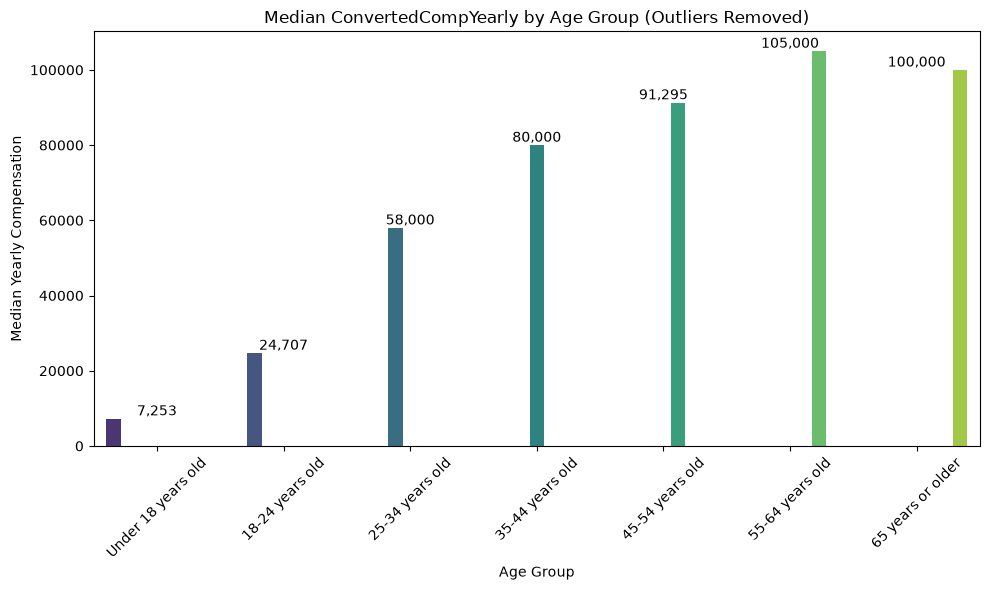

In [12]:
# Select relevant columns
plot_df = df[['Age', 'ConvertedCompYearly']].copy()

# Convert compensation to numeric
plot_df['ConvertedCompYearly'] = pd.to_numeric(
    plot_df['ConvertedCompYearly'],
    errors='coerce'
)

# Remove missing values
plot_df = plot_df.dropna()

# Remove outliers using IQR
Q1 = plot_df['ConvertedCompYearly'].quantile(0.25)
Q3 = plot_df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_df = plot_df[
    (plot_df['ConvertedCompYearly'] >= lower_bound) &
    (plot_df['ConvertedCompYearly'] <= upper_bound)
]

# Calculate median compensation by age group
median_comp = (
    plot_df.groupby('Age', as_index=False)['ConvertedCompYearly']
    .median()
)

# Define logical age order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Keep only valid age groups
median_comp = median_comp[
    median_comp['Age'].isin(age_order)
]

# Sort age groups
median_comp['Age'] = pd.Categorical(
    median_comp['Age'],
    categories=age_order,
    ordered=True
)

median_comp = median_comp.sort_values('Age')

# Create grouped bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=median_comp,
    x='Age',
    y='ConvertedCompYearly',
    hue='Age',
    palette='viridis',
    legend=False
)

plt.title('Median ConvertedCompYearly by Age Group (Outliers Removed)')
plt.xlabel('Age Group')
plt.ylabel('Median Yearly Compensation')
plt.xticks(rotation=45)

# Add value labels
for i, value in enumerate(median_comp['ConvertedCompYearly']):
    plt.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



/tmp/ipykernel_839/2509393042.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

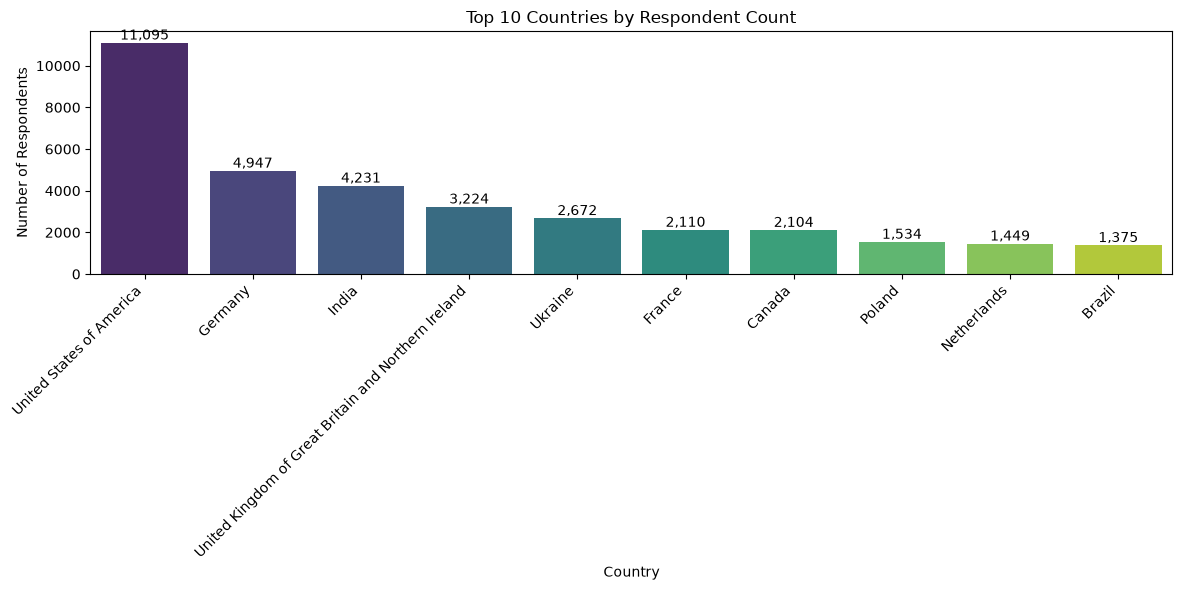

In [13]:
# Select Country column
plot_df = df[['Country']].copy()

# Remove missing values
plot_df = plot_df.dropna()

# Count respondents by country
country_counts = (
    plot_df['Country']
    .value_counts()
    .reset_index()
)

country_counts.columns = ['Country', 'Count']

# Display top 10 countries (optional)
country_counts = country_counts.head(10)

# Create bar chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=country_counts,
    x='Country',
    y='Count',
    palette='viridis'
)

plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')

# Add count labels
for i, count in enumerate(country_counts['Count']):
    plt.text(
        i,
        count,
        f'{count:,}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
